In [1]:
# Supply Chain Decision Intelligence — Exploratory Data Analysis

## Objective
'''Is EDA ka goal hai supplier/order-level delay patterns samajhna, taaki 
predictive models banane se pehle relevant factors identify ho sakein.

## Dataset
- **Source:** DataCo Smart Supply Chain Dataset (Kaggle)
- **Original size:** 180,519 rows × 53 columns
- **After cleaning:** 172,762 rows × 46 columns

## Data Cleaning Summary
- Cancelled/fraud-suspected shipments (`Delivery Status = 'Shipping canceled'`) 
  removed — their `Late_delivery_risk` labels were misleading (always 0, despite 
  never being delivered)
- PII columns removed (Customer Email, Password, First/Last Name, Street) — 
  privacy consideration, not useful for modeling
- Columns with excessive missing values removed (`Product Description` — 100% 
  missing, `Order Zipcode` — 86% missing)
- Date columns converted to proper `datetime` format
- Target variable (`Late_delivery_risk`) verified against actual shipping gap — 
  confirmed 100% consistent (no label noise)

## Business Questions Explored
1. Does shipping mode affect delay risk?
2. Is the scheduled-vs-actual shipping gap a strong delay predictor?
3. Which regions have highest delay risk?
4. Do certain product categories have higher delay risk?
5. Does product price affect delay risk?
6. Does customer segment affect delay risk?
7. Which customer states have highest delay risk?
8. Does late delivery affect order profit?
9. Does discount rate correlate with delay risk?'''

"Is EDA ka goal hai supplier/order-level delay patterns samajhna, taaki \npredictive models banane se pehle relevant factors identify ho sakein.\n\n## Dataset\n- **Source:** DataCo Smart Supply Chain Dataset (Kaggle)\n- **Original size:** 180,519 rows × 53 columns\n- **After cleaning:** 172,762 rows × 46 columns\n\n## Data Cleaning Summary\n- Cancelled/fraud-suspected shipments (`Delivery Status = 'Shipping canceled'`) \n  removed — their `Late_delivery_risk` labels were misleading (always 0, despite \n  never being delivered)\n- PII columns removed (Customer Email, Password, First/Last Name, Street) — \n  privacy consideration, not useful for modeling\n- Columns with excessive missing values removed (`Product Description` — 100% \n  missing, `Order Zipcode` — 86% missing)\n- Date columns converted to proper `datetime` format\n- Target variable (`Late_delivery_risk`) verified against actual shipping gap — \n  confirmed 100% consistent (no label noise)\n\n## Business Questions Explored\

In [2]:
import pandas as pd 
import numpy as np
print("Setup complete!")

Setup complete!


In [3]:
#dataset ka path define karna 
data_path = r"C:/Users/Rishj/OneDrive/Desktop/PROJECTS/supply_chain_intelligence/data/raw/DataCoSupplyChainDataset.csv"

In [4]:
#loading the dataset
df = pd.read_csv(data_path, encoding="cp1252")
#How will I identify on which factors I am going to perform EDA? How do I find out business insights, how will i enlist the business questions ?

In [5]:
# Pehli 5 rows dekho
df.head()



,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
#shows how many rows and columns are there in the dataset
df.shape

(180519, 53)

In [7]:
#shows the datatype of each column and missing values in each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [8]:
#shows the columns list of the dataset
df.columns.to_list()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [9]:
df.head

<bound method NDFrame.head of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per customer

In [10]:
# Target Variable Analysis
# - Late_delivery_risk (1 = late, 0 = not late) matches exactly with Delivery Status == "Late delivery" count (98,977 orders)
# - Class distribution: 54.8% late vs 45.2% not late — fairly balanced, with no severe class imbalance handling needed
# - Decision: Remove "Shipping canceled" orders (7,754 rows, 4.3%) because they represent a different business scenario (order never shipped) rather than a delivery timing issue

In [11]:
## Data Cleaning: Removing Cancelled Orders

#Removed "Shipping canceled" status (7,754 rows) since these represent orders that never shipped, not a delivery-timing outcome.
#Updated dataset:** 172,765 rows
#Class distribution (Late vs Not Late):**
#-Late delivery: 57.3%
#- Not late (Advance + On time): 42.7%
#Fairly balanced — no severe class imbalance handling required for modeling.

In [12]:
#cancelled shipments drop karo
#cancelled/fraud orders drop karo - inka late_delivery risk label misleading hoga, kyunki ye orders kabhi ship hi nahi hue.
df = df[df['Delivery Status'] != 'Shipping canceled'].copy()
print("Rows remaining:", df.shape[0])

Rows remaining: 172765


In [13]:
#PII (Personally Identifiable Information) columns ko drop karna, kyunki ye model ke liye useful nahi hai aur privacy risk bhi create karte hai.
#customer ki persona/sensitive information - model ke liye useless, as well as privacy risk bhi hai 
pii_columns = [
    'Customer Email', 'Customer Password', 'Customer Fname', 
    'Customer Lname', 'Customer Street'
]
useless_columns = ['Product Description', 'Order Zipcode', 'Product Image']  # yahan add kar diya

df = df.drop(columns=pii_columns + useless_columns)

In [14]:
print("Columns remaining after cleaning:", df.shape[1])

Columns remaining after cleaning: 45


In [15]:
#check the remaining missing values in the dataset
df.isnull().sum().sort_values(ascending=False).head(10)

Customer Zipcode                 3
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Type                             0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
dtype: int64

In [16]:
#date columns ko proper datetime format me convert karna
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

#check karo type sahi ban gaya 
df[['order date (DateOrders)', 'shipping date (DateOrders)']].dtypes

order date (DateOrders)       datetime64[us]
shipping date (DateOrders)    datetime64[us]
dtype: object

In [17]:
df.shape

(172765, 45)

In [18]:
#customer zipcode ke 3 values ko handle karna hai - 3 values missing hai, 1 value invalid hai (0), baki ke 2 values valid hai.
#sirf 3 rows missing hai drop kar dete hain 
df=df.dropna(subset=['Customer Zipcode'])
print("Final shape after handling missing values:", df.shape)

Final shape after handling missing values: (172762, 45)


In [19]:
#VERIFY THE TARGET VARIABLE LATE_DELIVERY_RISK
#fix the target variable late_delivery_risk, but it is mandatory to verify it which it is logically correct or not
#if late_delivery_risk=1 wale rows ka average shipping_gap positive (jaise 1-2+) hai or late_delivery_risk=0 wale rows ka average shipping_gap negative (jaise -1-2-) hai, then it is logically correct.
df['shipping_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df.groupby('Late_delivery_risk')['shipping_gap'].describe()

,count,mean,std,min,25%,50%,75%,max
Late_delivery_risk,,,,,,,,
0,73786.0,-0.84657,0.834068,-2.0,-2.0,-1.0,0.0,0.0
1,98976.0,1.61819,0.882529,1.0,1.0,1.0,2.0,4.0


In [20]:
#CHECK CLASS IMBALANCE
# Class imbalance check
print(df['Late_delivery_risk'].value_counts())
print()
print(df['Late_delivery_risk'].value_counts(normalize=True) * 100)

Late_delivery_risk
1    98976
0    73786
Name: count, dtype: int64

Late_delivery_risk
1    57.290376
0    42.709624
Name: proportion, dtype: float64


In [21]:
#BASIC VIZULAISATIONS

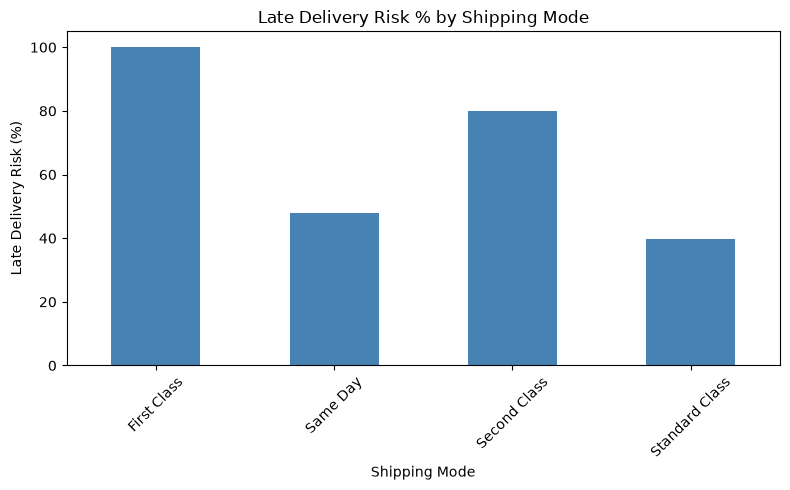

In [22]:
#Kya Shipping Mode (Standard/First/Second/Same Day Class) late delivery risk ko significantly affect karta hai?
import matplotlib.pyplot as plt

# Shipping Mode vs Late Delivery Risk
shipping_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].mean() * 100

shipping_delay.plot(kind='bar', color='steelblue', figsize=(8,5))
plt.title('Late Delivery Risk % by Shipping Mode')
plt.ylabel('Late Delivery Risk (%)')
plt.xlabel('Shipping Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
df.groupby('Shipping Mode')[['Days for shipment (scheduled)', 'Days for shipping (real)']].mean()

,Days for shipment (scheduled),Days for shipping (real)
Shipping Mode,,
First Class,1.0,2.000000
Same Day,0.0,0.479285
Second Class,2.0,3.993167
Standard Class,4.0,3.993699


In [24]:
### Insight A1: Shipping Mode vs Delay Risk
'''First Class aur Second Class modes 80-100% late delivery risk dikhate hain, 
lekin actual data se pata chalta hai ki inka delay "genuine slowness" nahi, 
balki "unrealistic scheduled windows" ki wajah se hai. Standard Class ka 
scheduled time (4 days) itna generous hai ki actual delivery (3.99 days avg) 
usme comfortably fit ho jaata hai. Business recommendation: First/Second Class 
ke scheduled delivery estimates ko realistic banaya jaye, ya to operational 
speed improve ki jaye taaki tight windows meet ho sakein.'''

'First Class aur Second Class modes 80-100% late delivery risk dikhate hain, \nlekin actual data se pata chalta hai ki inka delay "genuine slowness" nahi, \nbalki "unrealistic scheduled windows" ki wajah se hai. Standard Class ka \nscheduled time (4 days) itna generous hai ki actual delivery (3.99 days avg) \nusme comfortably fit ho jaata hai. Business recommendation: First/Second Class \nke scheduled delivery estimates ko realistic banaya jaye, ya to operational \nspeed improve ki jaye taaki tight windows meet ho sakein.'

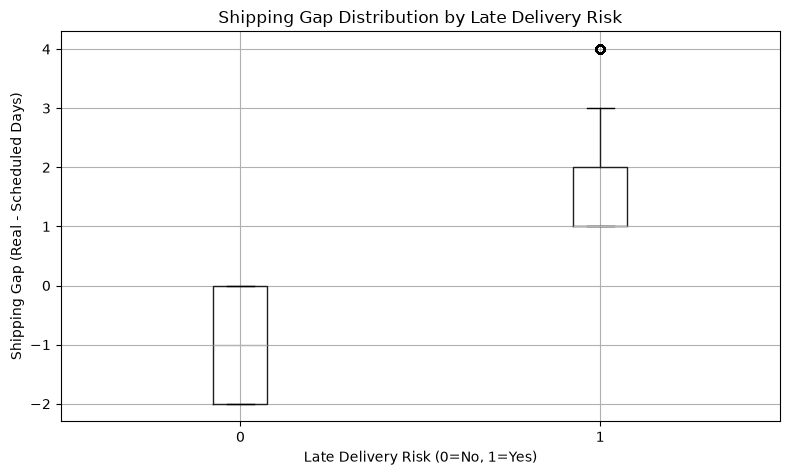

In [25]:
#Kya scheduled vs. actual shipping days ka gap ek strong delay predictor hai?
import matplotlib.pyplot as plt

# Shipping gap distribution by delay status
df.boxplot(column='shipping_gap', by='Late_delivery_risk', figsize=(8,5))
plt.title('Shipping Gap Distribution by Late Delivery Risk')
plt.suptitle('')  # removes default subtitle
plt.xlabel('Late Delivery Risk (0=No, 1=Yes)')
plt.ylabel('Shipping Gap (Real - Scheduled Days)')
plt.tight_layout()
plt.show()

In [26]:
### Insight A2: Shipping Gap as Predictor
'''Shipping gap (real days - scheduled days) perfectly separates late vs on-time 
orders (no overlap in boxplot) — confirming it's the exact formula target 
variable was derived from. **Important:** `Days for shipping (real)` and 
`shipping_gap` cannot be used as model features (data leakage), since these 
values are only known AFTER delivery happens. Only `Days for shipment 
(scheduled)` is usable as a legitimate predictive feature.'''

"Shipping gap (real days - scheduled days) perfectly separates late vs on-time \norders (no overlap in boxplot) — confirming it's the exact formula target \nvariable was derived from. **Important:** `Days for shipping (real)` and \n`shipping_gap` cannot be used as model features (data leakage), since these \nvalues are only known AFTER delivery happens. Only `Days for shipment \n(scheduled)` is usable as a legitimate predictive feature."

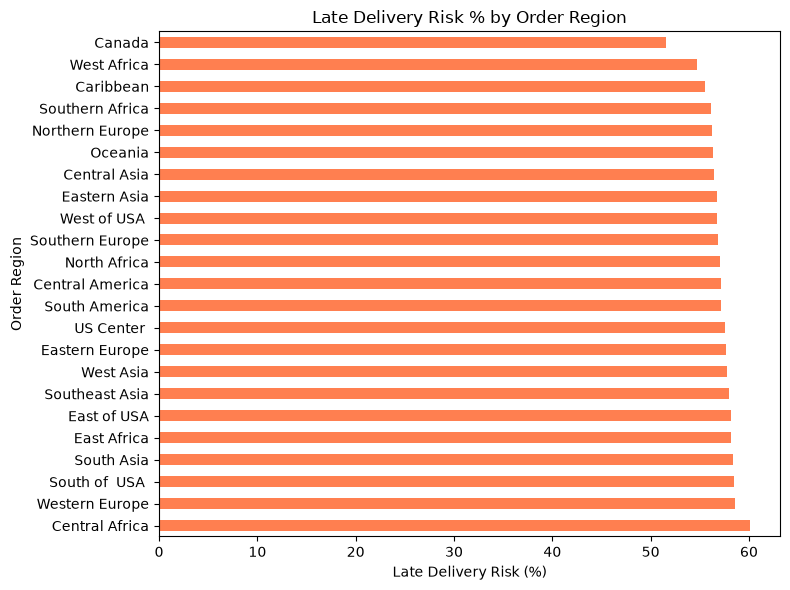

In [27]:
#Kaunse Order Region/Market (jaise LATAM, Europe, USCA) me delay risk sabse zyada hai?
region_delay = df.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100
region_delay.plot(kind='barh', color='coral', figsize=(8,6))
plt.title('Late Delivery Risk % by Order Region')
plt.xlabel('Late Delivery Risk (%)')
plt.tight_layout()
plt.show()

In [28]:
### Insight A3: Region vs Delay Risk
'''Order Region ka delay risk par significant differentiating impact nahi hai — 
saari regions 51-59% ke narrow range me hain (vs Shipping Mode jo 40-100% 
tak vary karta hai). Ye suggest karta hai ki delay **primarily operational/
logistics factor hai (shipping mode), na ki geographic factor**. Business 
recommendation: delay reduction strategies pe focus karte waqt, region-specific 
interventions ki jagah shipping mode/scheduling process ko improve karna 
zyada impactful hoga.'''

'Order Region ka delay risk par significant differentiating impact nahi hai — \nsaari regions 51-59% ke narrow range me hain (vs Shipping Mode jo 40-100% \ntak vary karta hai). Ye suggest karta hai ki delay **primarily operational/\nlogistics factor hai (shipping mode), na ki geographic factor**. Business \nrecommendation: delay reduction strategies pe focus karte waqt, region-specific \ninterventions ki jagah shipping mode/scheduling process ko improve karna \nzyada impactful hoga.'

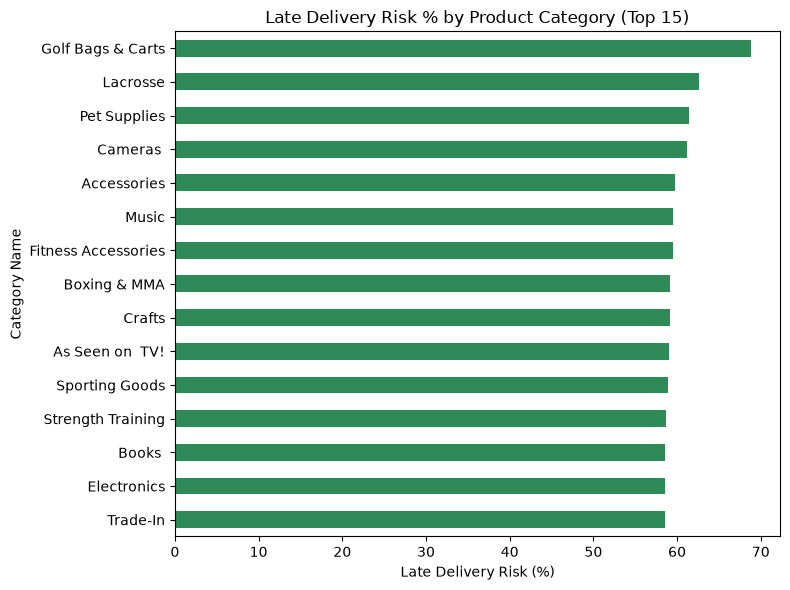

In [29]:
#Kya kuch specific product categories (jaise Sporting Goods, Fishing) doosron se zyada delay-prone hain?
category_delay = df.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

# Top 15 categories dikhate hain (kyunki bahut saari categories ho sakti hain)
category_delay.head(15).plot(kind='barh', color='seagreen', figsize=(8,6))
plt.title('Late Delivery Risk % by Product Category (Top 15)')
plt.xlabel('Late Delivery Risk (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
### Insight B1: Product Category vs Delay Risk
'''Product category ka delay risk par moderate impact hai (58-69% range) — 
Region se zyada, lekin Shipping Mode se kam significant. Niche/specialty 
categories (Golf Bags & Carts, Lacrosse, Boxing & MMA) sabse zyada delay-
prone hain, jabki high-volume categories (Books, Electronics) comparatively 
kam risky hain. Ye pattern suggest karta hai ki lower-demand/niche products 
ka supply chain kam optimized/streamlined ho sakta hai. Business 
recommendation: niche category suppliers ke saath delivery process review 
karna, ya inke liye zyada buffer time allocate karna.'''

'Product category ka delay risk par moderate impact hai (58-69% range) — \nRegion se zyada, lekin Shipping Mode se kam significant. Niche/specialty \ncategories (Golf Bags & Carts, Lacrosse, Boxing & MMA) sabse zyada delay-\nprone hain, jabki high-volume categories (Books, Electronics) comparatively \nkam risky hain. Ye pattern suggest karta hai ki lower-demand/niche products \nka supply chain kam optimized/streamlined ho sakta hai. Business \nrecommendation: niche category suppliers ke saath delivery process review \nkarna, ya inke liye zyada buffer time allocate karna.'

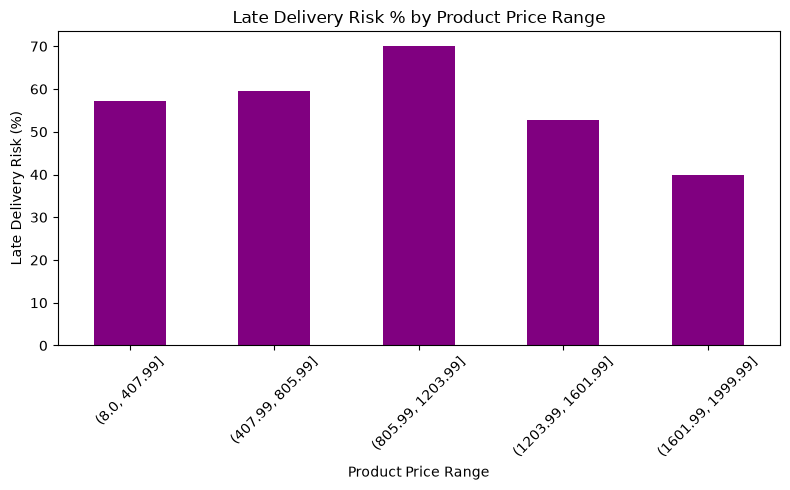

In [31]:
#Kya higher-priced products ya bulk orders (quantity) delay risk ko badhate hain?
# Product Price ko groups me baanto (bins)
df['price_bin'] = pd.cut(df['Product Price'], bins=5)

price_delay = df.groupby('price_bin')['Late_delivery_risk'].mean() * 100

price_delay.plot(kind='bar', color='purple', figsize=(8,5))
plt.title('Late Delivery Risk % by Product Price Range')
plt.ylabel('Late Delivery Risk (%)')
plt.xlabel('Product Price Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
### Insight B2: Product Price vs Delay Risk
'''Product price aur delay risk ke beech **linear relationship nahi hai**. 
Mid-range products (₹806-1204) sabse zyada delay-prone hain (70%), jabki 
premium products (₹1600+) sabse kam delay face karte hain (40%). Ye 
suggest karta hai ki high-value/premium products ko company priority 
handling deti hai (better logistics, faster processing) — jabki mid-range 
products standard/generic handling process se guzarte hain, jisme zyada 
variability hai. Business recommendation: mid-range product category ke 
liye bhi premium-jaisa prioritized handling consider karna.'''

'Product price aur delay risk ke beech **linear relationship nahi hai**. \nMid-range products (₹806-1204) sabse zyada delay-prone hain (70%), jabki \npremium products (₹1600+) sabse kam delay face karte hain (40%). Ye \nsuggest karta hai ki high-value/premium products ko company priority \nhandling deti hai (better logistics, faster processing) — jabki mid-range \nproducts standard/generic handling process se guzarte hain, jisme zyada \nvariability hai. Business recommendation: mid-range product category ke \nliye bhi premium-jaisa prioritized handling consider karna.'

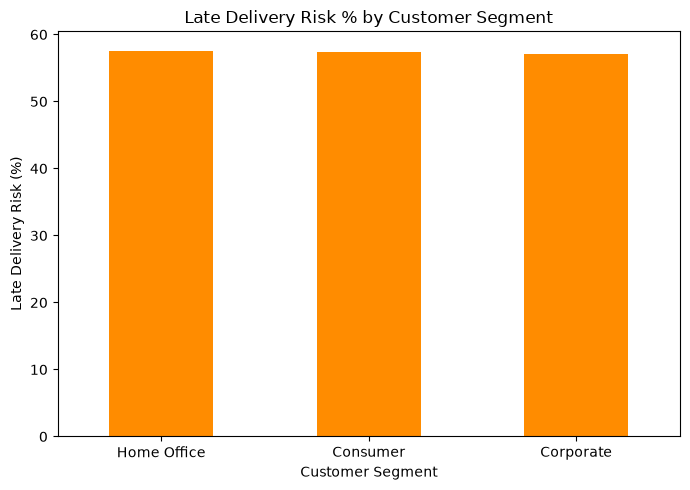

In [33]:
#Kya Customer Segment (Consumer/Corporate/Home Office) ke hisaab se delay pattern alag hai?
segment_delay = df.groupby('Customer Segment')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

segment_delay.plot(kind='bar', color='darkorange', figsize=(7,5))
plt.title('Late Delivery Risk % by Customer Segment')
plt.ylabel('Late Delivery Risk (%)')
plt.xlabel('Customer Segment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
### Insight C1: Customer Segment vs Delay Risk
'''Customer Segment (Home Office/Consumer/Corporate) ka delay risk par 
practically **koi impact nahi hai** — teeno segments 56-58% range me hain, 
jo negligible variation hai. Ye batata hai ki delivery delays customer type 
ke basis pe discriminate nahi karte — matlab ye ek **operational issue hai, 
customer-relationship issue nahi**. Business recommendation: delay reduction 
initiatives customer segment ke hisaab se customize karne ki zaroorat nahi 
hai — ek uniform, operations-focused solution sabhi segments ke liye equally 
effective hoga.'''

'Customer Segment (Home Office/Consumer/Corporate) ka delay risk par \npractically **koi impact nahi hai** — teeno segments 56-58% range me hain, \njo negligible variation hai. Ye batata hai ki delivery delays customer type \nke basis pe discriminate nahi karte — matlab ye ek **operational issue hai, \ncustomer-relationship issue nahi**. Business recommendation: delay reduction \ninitiatives customer segment ke hisaab se customize karne ki zaroorat nahi \nhai — ek uniform, operations-focused solution sabhi segments ke liye equally \neffective hoga.'

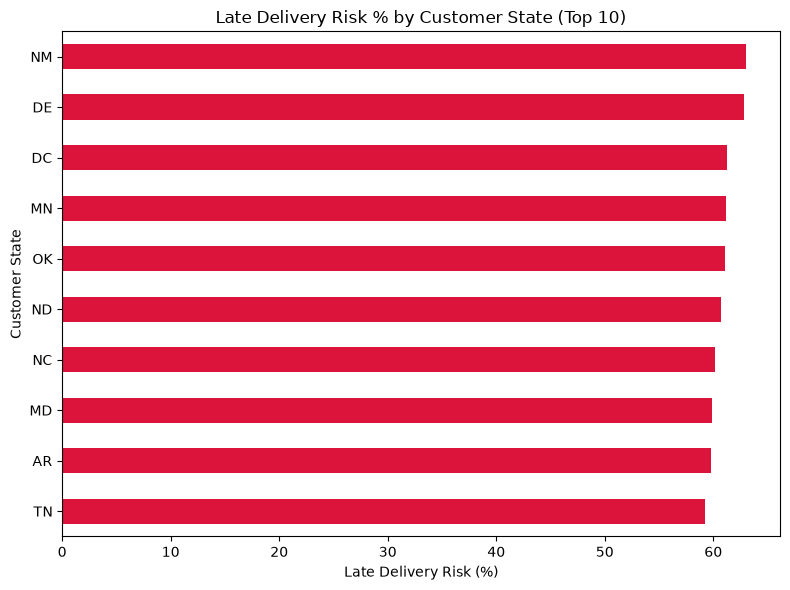

In [35]:
#Kaunse Customer States/Cities consistently zyada delay face karte hain?
state_delay = df.groupby('Customer State')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

state_delay.head(10).plot(kind='barh', color='crimson', figsize=(8,6))
plt.title('Late Delivery Risk % by Customer State (Top 10)')
plt.xlabel('Late Delivery Risk (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [36]:
# Check karo ki top states me kitne orders hain (reliability check)
state_counts = df['Customer State'].value_counts()
top_delay_states = state_delay.head(10).index

print(state_counts[top_delay_states])

Customer State
NM     908
DE     258
DC     547
MN     626
OK     226
ND     201
NC    1873
MD    2298
AR     159
TN    1502
Name: count, dtype: int64


In [37]:
### Insight C2: Customer State vs Delay Risk
'''Top 10 states me delay risk 59-63% ke narrow range me hai, jo state-level 
geography ka delay par weak impact confirm karta hai — Insight A3 (Region) 
ke consistent. Sample sizes (159-2298 orders per state) reasonably sufficient 
hain reliable estimates ke liye. Business recommendation: state/region-specific 
delay interventions ki jagah, universal operational improvements (jaise 
shipping mode/scheduling fix) zyada impactful honge.'''

'Top 10 states me delay risk 59-63% ke narrow range me hai, jo state-level \ngeography ka delay par weak impact confirm karta hai — Insight A3 (Region) \nke consistent. Sample sizes (159-2298 orders per state) reasonably sufficient \nhain reliable estimates ke liye. Business recommendation: state/region-specific \ndelay interventions ki jagah, universal operational improvements (jaise \nshipping mode/scheduling fix) zyada impactful honge.'

                         mean  median           sum
Late_delivery_risk                                 
0                   22.582848   31.68  1.666298e+06
1                   21.621255   31.43  2.139985e+06


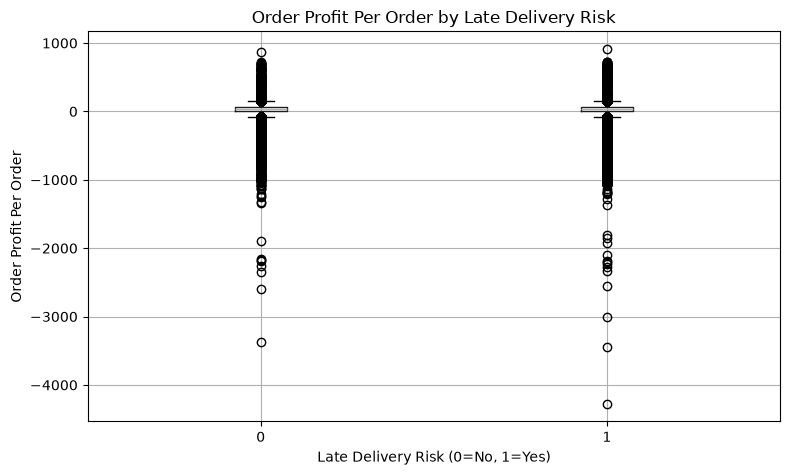

In [38]:
#Late delivery ka Benefit per order / Order Profit Per Order par kya asar padta hai — kya late orders profitability kam karte hain?
profit_by_delay = df.groupby('Late_delivery_risk')['Order Profit Per Order'].agg(['mean', 'median', 'sum'])
print(profit_by_delay)

# Visualization
import matplotlib.pyplot as plt

df.boxplot(column='Order Profit Per Order', by='Late_delivery_risk', figsize=(8,5))
plt.title('Order Profit Per Order by Late Delivery Risk')
plt.suptitle('')
plt.xlabel('Late Delivery Risk (0=No, 1=Yes)')
plt.ylabel('Order Profit Per Order')
plt.tight_layout()
plt.show()

In [39]:
### Insight D1: Financial Impact of Late Delivery
'''Late delivery ka `Order Profit Per Order` par **koi meaningful direct impact 
nahi** hai (₹22.58 vs ₹21.62 mean, negligible difference). Ye is wajah se hai 
kyunki profit order-placement time par hi determine ho jaata hai (product 
price/cost basis), aur delivery outcome se independent hai in this dataset. 

**Important caveat:** Ye sirf **direct/recorded profit** ko capture karta hai. 
Late delivery ke **indirect costs** — jaise customer churn, negative reviews, 
future order loss, refund/complaint handling cost — is dataset me track nahi 
hote, aur wo alag se significant ho sakte hain. Business recommendation: 
company ko customer satisfaction/retention metrics track karne chahiye late 
delivery ke against, na ki sirf per-order accounting profit.'''

'Late delivery ka `Order Profit Per Order` par **koi meaningful direct impact \nnahi** hai (₹22.58 vs ₹21.62 mean, negligible difference). Ye is wajah se hai \nkyunki profit order-placement time par hi determine ho jaata hai (product \nprice/cost basis), aur delivery outcome se independent hai in this dataset. \n\n**Important caveat:** Ye sirf **direct/recorded profit** ko capture karta hai. \nLate delivery ke **indirect costs** — jaise customer churn, negative reviews, \nfuture order loss, refund/complaint handling cost — is dataset me track nahi \nhote, aur wo alag se significant ho sakte hain. Business recommendation: \ncompany ko customer satisfaction/retention metrics track karne chahiye late \ndelivery ke against, na ki sirf per-order accounting profit.'

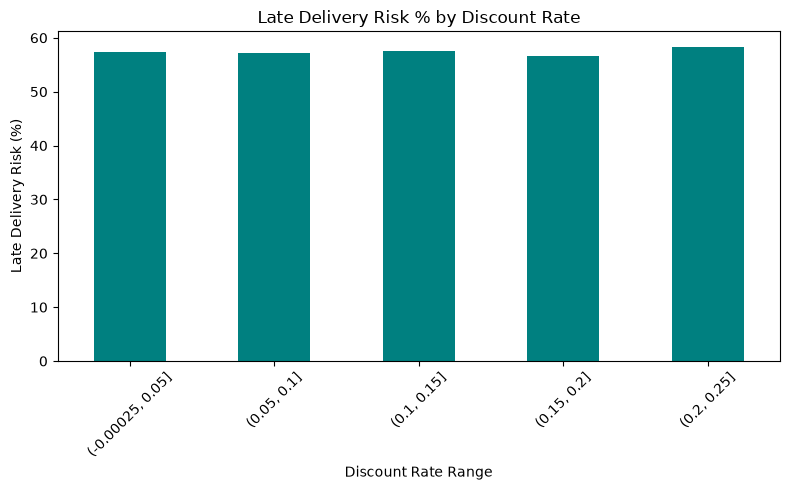

In [40]:
#Kya discount rate (Order Item Discount Rate) delay ke saath correlate karta hai (jaise discounted orders zyada delay hote hain)?
df['discount_bin'] = pd.cut(df['Order Item Discount Rate'], bins=5)

discount_delay = df.groupby('discount_bin')['Late_delivery_risk'].mean() * 100

discount_delay.plot(kind='bar', color='teal', figsize=(8,5))
plt.title('Late Delivery Risk % by Discount Rate')
plt.ylabel('Late Delivery Risk (%)')
plt.xlabel('Discount Rate Range')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
### Insight D2: Discount Rate vs Delay Risk
'''Discount rate ka delay risk par **koi meaningful impact nahi** hai — saare 
discount bins (0-25%) 56-58% range me consistent hain. Ye batata hai ki 
discounted orders ko company alag se deprioritize nahi karti processing 
me — delivery process discount status se independent operate karta hai. 
Business recommendation: discount-based delay concerns (jaise "sale season 
me zyada delay hoga") is data ke basis par unfounded hain — koi special 
handling adjustment ki zaroorat nahi.'''

'Discount rate ka delay risk par **koi meaningful impact nahi** hai — saare \ndiscount bins (0-25%) 56-58% range me consistent hain. Ye batata hai ki \ndiscounted orders ko company alag se deprioritize nahi karti processing \nme — delivery process discount status se independent operate karta hai. \nBusiness recommendation: discount-based delay concerns (jaise "sale season \nme zyada delay hoga") is data ke basis par unfounded hain — koi special \nhandling adjustment ki zaroorat nahi.'

In [42]:
## 📊 Final Summary — Key Findings
'''
| Factor | Impact Strength | Key Finding |
|---|---|---|
| **Shipping Mode** | 🔴 Very Strong (40–100%) | Tight scheduled windows lead to higher "late" flag rates, even when actual delivery speed is comparable |
| **Product Price** | 🟡 Moderate (40–70%) | Non-linear relationship — mid-range products (₹806–1204) are riskiest, premium products are safest |
| **Product Category** | 🟡 Moderate (58–69%) | Niche categories (Golf Bags & Carts, Lacrosse) show higher delay risk than high-volume categories |
| **Order Region** | 🟢 Weak (51–59%) | Minimal geographic effect on delay risk |
| **Customer State** | 🟢 Weak (59–63%) | Consistent with region-level finding |
| **Customer Segment** | ⚪ Negligible (57–58%) | No meaningful difference across Consumer/Corporate/Home Office |
| **Order Profit** | ⚪ Negligible (₹21.6 vs ₹22.6) | Late delivery does not directly affect recorded per-order profit |
| **Discount Rate** | ⚪ Negligible (56–58%) | No relationship between discount level and delay risk |

## 🎯 Master Insight

Late delivery risk is primarily an **operational/logistics issue** — driven 
largely by unrealistic scheduled delivery windows (especially in First Class 
and Second Class shipping) — rather than being influenced by customer 
demographics, geography, or pricing factors. The most actionable lever for 
reducing delay risk is **revising shipping mode scheduling expectations** 
to be more realistic relative to actual fulfillment capabilities.

## ⚠️ Data Leakage Note
`Days for shipping (real)` and the derived `shipping_gap` column are 
**excluded from model features**, since these values are only known after 
delivery occurs and directly determine the target variable — including them 
would cause data leakage. Only `Days for shipment (scheduled)` is a valid 
pre-delivery predictive feature.

## Next Steps
Proceed to feature engineering — encoding categorical variables, creating 
supplier/category reliability scores, and preparing the dataset for model 
training.'''

'\n| Factor | Impact Strength | Key Finding |\n|---|---|---|\n| **Shipping Mode** | 🔴 Very Strong (40–100%) | Tight scheduled windows lead to higher "late" flag rates, even when actual delivery speed is comparable |\n| **Product Price** | 🟡 Moderate (40–70%) | Non-linear relationship — mid-range products (₹806–1204) are riskiest, premium products are safest |\n| **Product Category** | 🟡 Moderate (58–69%) | Niche categories (Golf Bags & Carts, Lacrosse) show higher delay risk than high-volume categories |\n| **Order Region** | 🟢 Weak (51–59%) | Minimal geographic effect on delay risk |\n| **Customer State** | 🟢 Weak (59–63%) | Consistent with region-level finding |\n| **Customer Segment** | ⚪ Negligible (57–58%) | No meaningful difference across Consumer/Corporate/Home Office |\n| **Order Profit** | ⚪ Negligible (₹21.6 vs ₹22.6) | Late delivery does not directly affect recorded per-order profit |\n| **Discount Rate** | ⚪ Negligible (56–58%) | No relationship between discount level and d

In [43]:
df = df.drop(columns=['price_bin', 'discount_bin'])
print("Columns remaining:", df.shape[1])

Columns remaining: 46


In [44]:
df.to_csv(r"C:/Users/Rishj/OneDrive/Desktop/PROJECTS/supply_chain_intelligence/data/processed/eda_cleaned_dataset.csv", index=False)